In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path

variable2 = 'shelfmelt'
y2sec=-365.25*24*3600
factor = y2sec/10**3
pth = pth_helene

variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack
# variable2 = 'iareafl'
# factor = 1
# pth = pth_helene

# variable2 = 'iareagr'
# factor = 1
# pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/recalc_{variable2}_lin_ms/'
fname = f'average_{variable2}_'

In [2]:

 
expnames = ['expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_ms2k = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')
df_ms_n2k = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_TFuntil2K.csv')

df_ms = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max.csv')
df_ms_n = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept.csv')

df_ms2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_n2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_intercept_time2100.csv')

In [3]:
pds_m = [df_ms]
pds_n = [df_ms_n]
methods = ['$BMB_{max}$']

In [4]:
dic_area_of_interest ={}

dic_area_of_interest['AIS'] = ['']

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'


In [5]:
exp

'expAE05'

In [6]:
df = df_org[df_org['Experiment']== exp]

In [7]:
Models = ['UCM_Yelmo', 'UTAS_ElmerIce', 'DC_ISSM']

In [8]:
fpath='./figs/recalc_shelfmelt_overview/'
fname='recalc_shelfmelt_lin_ms_'

In [9]:
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    df =  df[df['Model'].isin(Models)].reset_index(drop = True)
    df

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_10,sector_11,sector_12,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS
0,expAE05,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,expAE05,UCM_Yelmo,/Volumes/CrucialX8/computing/data/antarctica/i...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,expAE05,UTAS_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
methods

['$BMB_{max}$']

The path './figs/recalc_shelfmelt_overview/' already exists.


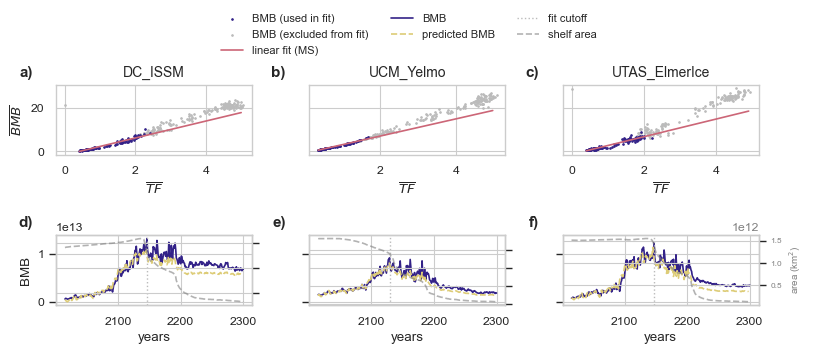

In [84]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
dic_all_err = {}

# time-of-max-BMB cutoffs, used to mark which portion of each time series
# was actually used to fit the MS regression
df_time = pd.read_csv('./tables/time_maximum_BMB.csv')

method = methods[0]
df_ms_method = pds_m[0]
df_ms_n_method = pds_n[0]

panel_labels_top = ['a)', 'b)', 'c)']
panel_labels_bot = ['d)', 'e)', 'f)']

ax3_first = None

for key in dic_area_of_interest.keys():
    dic_key = {}

    lst = dic_area_of_interest[key]
    # column(s) in df_time matching this region, for the fit-cutoff lookup
    time_cols = ['AIS'] if lst == [''] else [s.lstrip('_') for s in lst]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#117733', '#332288', '#DDCC77', '#CC6677']
    color_excl = '#BBBBBB'
    fs = 8

    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    for j,exp in enumerate(expnames):
        dic_exp ={}
        # layout matches Fig S3: top row = scatter/fit, bottom row = time series/prediction,
        # one column per model (instead of one column per method, since there's only one method here)
        f,ax = plt.subplots(2, len(Models), figsize=(a4_width, a4_height/3.3), sharey='row', squeeze=False)

        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        df =  df[df['Model'].isin(Models)].reset_index(drop = True)

        ms_exp =df_ms_method[df_ms_method['Experiment']== exp].reset_index(drop=True)
        ms_exp= ms_exp[ms_exp['Model'].isin(Models)].reset_index(drop = True)
        ms_n_exp =df_ms_n_method[df_ms_n_method['Experiment']== exp].reset_index(drop=True)
        ms_n_exp= ms_n_exp[ms_n_exp['Model'].isin(Models)].reset_index(drop = True)

        for i in range (df.shape[0]):

            pth_way = df.iloc[i].Path
            #get shelf area

            pth_bmb = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'


            d3 = xr.open_dataset(pth_bmb,decode_times=False )

            #get shelf area
            pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal foring
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model



            pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'

            d4 = xr.open_dataset(pth_var3,decode_times=False )

            tmin = np.min([d2.time.size,d3.time.size,d4.time.size])
            #melting per area
            the_ys = np.zeros((len(lst),tmin))
            the_areas = np.zeros((len(lst),tmin))
            the_tfs = np.zeros((len(lst),tmin))

            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                the_areas[k,:]= d2[f'{variable}{nm}'].values[:tmin]
                the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:tmin]*the_areas[k,:]

            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            TF = np.sum( the_tfs,axis = 0)/area

            ms = ms_exp.iloc[i][key]
            ms_n = ms_n_exp.iloc[i][key]

            # --- fit-period cutoff for this model, used to mark which points
            # were actually used to fit the MS regression (reviewer request) ---
            t_row = df_time[(df_time['Experiment']==df.iloc[i].Experiment) & (df_time['Model']==df.iloc[i].Model)]
            t_max_val = np.nanmax(t_row[time_cols].values[0].astype(float)) if len(t_row)>0 else np.nan
            if method == '$BMB_{max2100}$':
                cutoff_time = np.nanmin([t_max_val, 2100])
            else:
                cutoff_time = t_max_val
            time_vals = d3.time.values[:tmin]
            used_mask = time_vals <= cutoff_time
            if method == '$BMB_{max2K}$':
                used_mask = used_mask & (TF <= 2)
                # the fit cutoff for this method is whichever comes first: time-of-max-BMB,
                # or the first time TF exceeds 2K (used_mask requires TF<=2, so the drawn
                # cutoff line should reflect that, not just time-of-max-BMB)
                tf_over_idx = np.where((time_vals <= cutoff_time) & (TF > 2))[0]
                if tf_over_idx.size > 0:
                    cutoff_time = np.nanmin([cutoff_time, time_vals[tf_over_idx[0]]])

            # ---- bottom row: BMB time series + predicted BMB ----
            ax2 = ax[1,i]

            if i ==0:
                ax2.plot(d3.time[:tmin],y ,color = colors[1],label = 'BMB')
                ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = colors[2],linestyle ='dashed',label = 'predicted BMB')
            else:
                ax2.plot(d3.time[:tmin],y ,color = colors[1])
                ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = colors[2],linestyle ='dashed')

            if np.isfinite(cutoff_time):
                ax2.axvline(cutoff_time, color=color_excl, linestyle=':', linewidth=1.0,
                            label='fit cutoff' if i==0 else None)

            # shelf area on a secondary y-axis, same style as Fig S2
            ax3 = ax2.twinx()
            ax3.plot(d3.time[:tmin], area, linestyle='--', color='grey', alpha=0.6,
                     label='shelf area' if i==0 else None)
            ax3.tick_params(axis='y', labelcolor='grey', labelsize=6)
            if i == len(Models)-1:
                ax3.set_ylabel('area (km$^2$)', fontsize=7, color='grey')
            else:
                ax3.set_yticklabels([])
            if i==0:
                ax3_first = ax3

            err = (ms*TF*area +ms_n*area -y)**2
            msk = np.isnan(err) | (y == 0)
            rmse = (np.sum(err[~msk])/err[~msk].size)**0.5
            if len(err[~msk]) !=0:
                prmse = (( (1/err[~msk].size)*np.sum(err[~msk]))/np.sum(y[~msk]**2))**0.5 *100 # %
                dic_exp[df.iloc[i].Model] =prmse.copy()
            else:
                prmse = np.nan
                dic_exp[df.iloc[i].Model] =np.nan

            df_info_exp = df_info[df_info['Experiment']==exp]
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model

            df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
            meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
            icefront =  df_info_exp_model['ice front'].values[0]
            ax2.set_xlabel('years')
            if i ==0:
                ax2.set_ylabel('BMB')
            ax2.text(-0.12, 1.08, panel_labels_bot[i], transform=ax2.transAxes,
                      fontsize=11, fontweight='bold', va='bottom', ha='right')

            ################### top row: scatter plot ###################
            ax2 = ax[0,i]
            y_avg = y/area
            ax2.scatter(TF[used_mask],y_avg[used_mask],s = 1.2,color =colors[1],
                        label = 'BMB (used in fit)' if i==0 else None, zorder=3)
            ax2.scatter(TF[~used_mask],y_avg[~used_mask],s = 1.2,color =color_excl,
                        label = 'BMB (excluded from fit)' if i==0 else None, zorder=2)
            TF_even = np.arange(np.nanmin(TF[:-1]),np.nanmax(TF[:-1]),0.1)
            ax2.plot(TF_even,TF_even*ms+ms_n,color = colors[3],
                     label = 'linear fit (MS)' if i==0 else None, zorder=4)

            ax2.set_title(df.iloc[i].Model, fontsize=10)
            ax2.set_xlabel('$\overline{TF}$')
            if i ==0:
                ax2.set_ylabel('$\overline{BMB}$')
            ax2.text(-0.12, 1.08, panel_labels_top[i], transform=ax2.transAxes,
                      fontsize=11, fontweight='bold', va='bottom', ha='right')

        dic_key[exp]=dic_exp.copy()

        dic_all_err[key] = dic_key.copy()

handles, labels = ax[0,0].get_legend_handles_labels()
h2, l2 = ax[1,0].get_legend_handles_labels()
handles += h2
labels += l2
if ax3_first is not None:
    h3, l3 = ax3_first.get_legend_handles_labels()
    handles += h3
    labels += l3
# f.suptitle(f'{method} fit, {exp}, {list(dic_area_of_interest.keys())[0]}', fontsize=11, y=1.08)
f.tight_layout(rect=[0, 0, 1, 0.88])
f.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0), fontsize=8, frameon=False)
f.savefig('figs/SI/GoodExample_BMBmax_expAE05_AIS.jpeg', bbox_inches='tight', dpi=200)
f.savefig('figs/SI/GoodExample_BMBmax_expAE05_AIS.pdf', bbox_inches='tight')


The path './figs/recalc_shelfmelt_overview/' already exists.


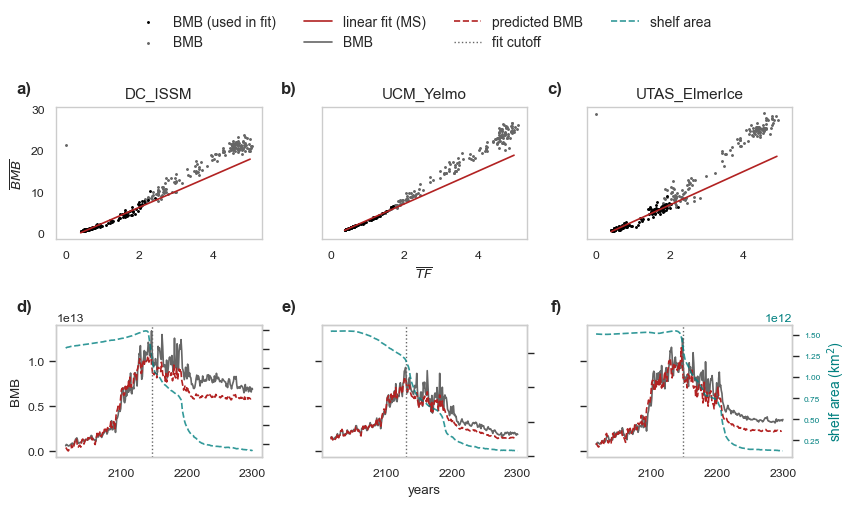

In [12]:
# --- v2: shared x-axis per row, bigger panels, black=actual BMB / red=prediction & fit / blue=shelf area ---
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
dic_all_err = {}
# time-of-max-BMB cutoffs, used to mark which portion of each time series
# was actually used to fit the MS regression
df_time = pd.read_csv('./tables/time_maximum_BMB.csv')
method = methods[0]
df_ms_method = pds_m[0]
df_ms_n_method = pds_n[0]
panel_labels_top = ['a)', 'b)', 'c)']
panel_labels_bot = ['d)', 'e)', 'f)']
color_bmb = 'black'
# color_fit = '#D62728'
color_fit = 'firebrick'      # predicted BMB (bottom row) and linear MS fit (top row)
# predicted BMB (bottom row) and linear MS fit (top row)
color_excl = '#666666'     # points/time not used in the fit
color_area = 'teal'    # shelf area, own distinct color on the secondary axis
ax3_first = None
for key in dic_area_of_interest.keys():
    dic_key = {}
    lst = dic_area_of_interest[key]
    # column(s) in df_time matching this region, for the fit-cutoff lookup
    time_cols = ['AIS'] if lst == [''] else [s.lstrip('_') for s in lst]
    a4_width = 8.27  # inches
    a4_height = 11.69
    fs = 8
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    for j,exp in enumerate(expnames):
        dic_exp ={}
        # bigger panels; x-axis synced (and visually aligned) across the 3 columns within each row
        f,ax = plt.subplots(2, len(Models), figsize=(8.27*1.05, 11.69/2.3), sharey='row', sharex='row', squeeze=False)
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        df =  df[df['Model'].isin(Models)].reset_index(drop = True)
        ms_exp =df_ms_method[df_ms_method['Experiment']== exp].reset_index(drop=True)
        ms_exp= ms_exp[ms_exp['Model'].isin(Models)].reset_index(drop = True)
        ms_n_exp =df_ms_n_method[df_ms_n_method['Experiment']== exp].reset_index(drop=True)
        ms_n_exp= ms_n_exp[ms_n_exp['Model'].isin(Models)].reset_index(drop = True)
        for i in range (df.shape[0]):
            pth_way = df.iloc[i].Path
            #get shelf area
            pth_bmb = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            d3 = xr.open_dataset(pth_bmb,decode_times=False )
            #get shelf area
            pth_area = f'{pth_helene}/{df.iloc[i].Experiment}/{variable}/computed_{variable}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            d2 = xr.open_dataset(pth_area,decode_times=False )
            #thermal foring
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
            pth_var3 = f'{pth3}/{df.iloc[i].Experiment}/{variable3}/computed_{variable3}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            d4 = xr.open_dataset(pth_var3,decode_times=False )
            tmin = np.min([d2.time.size,d3.time.size,d4.time.size])
            #melting per area
            the_ys = np.zeros((len(lst),tmin))
            the_areas = np.zeros((len(lst),tmin))
            the_tfs = np.zeros((len(lst),tmin))
            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                the_areas[k,:]= d2[f'{variable}{nm}'].values[:tmin]
                the_tfs[k,:]= d4[f'{variable3}{nm}'].values[:tmin]*the_areas[k,:]
            y = np.sum(the_ys ,axis =0)
            area = np.sum( the_areas,axis = 0)
            TF = np.sum( the_tfs,axis = 0)/area
            ms = ms_exp.iloc[i][key]
            ms_n = ms_n_exp.iloc[i][key]
            # --- fit-period cutoff for this model, used to mark which points
            # were actually used to fit the MS regression (reviewer request) ---
            t_row = df_time[(df_time['Experiment']==df.iloc[i].Experiment) & (df_time['Model']==df.iloc[i].Model)]
            t_max_val = np.nanmax(t_row[time_cols].values[0].astype(float)) if len(t_row)>0 else np.nan
            if method == '$BMB_{max2100}$':
                cutoff_time = np.nanmin([t_max_val, 2100])
            else:
                cutoff_time = t_max_val
            time_vals = d3.time.values[:tmin]
            used_mask = time_vals <= cutoff_time
            if method == '$BMB_{max2K}$':
                used_mask = used_mask & (TF <= 2)
                # the fit cutoff for this method is whichever comes first: time-of-max-BMB,
                # or the first time TF exceeds 2K (used_mask requires TF<=2, so the drawn
                # cutoff line should reflect that, not just time-of-max-BMB)
                tf_over_idx = np.where((time_vals <= cutoff_time) & (TF > 2))[0]
                if tf_over_idx.size > 0:
                    cutoff_time = np.nanmin([cutoff_time, time_vals[tf_over_idx[0]]])
            # ---- bottom row: BMB time series + predicted BMB ----
            ax2 = ax[1,i]
            if i ==0:
                ax2.plot(d3.time[:tmin],y ,color =color_excl,label = 'BMB')
                ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = color_fit,linestyle ='dashed',label = 'predicted BMB')
            else:
                ax2.plot(d3.time[:tmin],y ,color =  color_excl)
                ax2.plot(d3.time[:tmin][:-2],ms*TF[:-2]*area[:-2] +ms_n*area[:-2],color = color_fit,linestyle ='dashed')
            if np.isfinite(cutoff_time):
                ax2.axvline(cutoff_time, color=color_excl, linestyle=':', linewidth=1.0,
                            label='fit cutoff' if i==0 else None)
            # shelf area on a secondary y-axis, own distinct color
            ax3 = ax2.twinx()
            ax3.plot(d3.time[:tmin], area, linestyle='--', color=color_area, alpha=0.8,
                     label='shelf area' if i==0 else None)
            ax3.tick_params(axis='y', labelcolor=color_area, labelsize=6)
            if i == len(Models)-1:
                ax3.set_ylabel('shelf area (km$^2$)', fontsize=10, color=color_area)
            else:
                ax3.set_yticklabels([])
            if i==0:
                ax3_first = ax3
            err = (ms*TF*area +ms_n*area -y)**2
            msk = np.isnan(err) | (y == 0)
            rmse = (np.sum(err[~msk])/err[~msk].size)**0.5
            if len(err[~msk]) !=0:
                prmse = (( (1/err[~msk].size)*np.sum(err[~msk]))/np.sum(y[~msk]**2))**0.5 *100 # %
                dic_exp[df.iloc[i].Model] =prmse.copy()
            else:
                prmse = np.nan
                dic_exp[df.iloc[i].Model] =np.nan
            df_info_exp = df_info[df_info['Experiment']==exp]
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
            df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
            meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
            icefront =  df_info_exp_model['ice front'].values[0]
            # x-axis label only once per row (middle column), since x is now shared across the row
            if i ==1:
                ax2.set_xlabel('years')
            if i ==0:
                ax2.set_ylabel('BMB')
            ax2.text(-0.12, 1.08, panel_labels_bot[i], transform=ax2.transAxes,
                      fontsize=12, fontweight='bold', va='bottom', ha='right')
            ax2.grid(False)
            ax3.grid(False)

            ################### top row: scatter plot ###################
            ax2 = ax[0,i]
            y_avg = y/area
            ax2.scatter(TF[used_mask],y_avg[used_mask],s = 1.6,color =color_bmb,
                        label = 'BMB (used in fit)' if i==0 else None, zorder=3)
            ax2.scatter(TF[~used_mask],y_avg[~used_mask],s = 1.6,color =color_excl,
                        label = 'BMB ' if i==0 else None, zorder=2)
            TF_even = np.arange(np.nanmin(TF[:-1]),np.nanmax(TF[:-1]),0.1)
            ax2.plot(TF_even,TF_even*ms+ms_n,color = color_fit,
                     label = 'linear fit (MS)' if i==0 else None, zorder=4)
            ax2.set_title(df.iloc[i].Model, fontsize=11)
            if i ==1:
                ax2.set_xlabel('$\overline{TF}$')
            if i ==0:
                ax2.set_ylabel('$\overline{BMB}$')
            ax2.text(-0.12, 1.08, panel_labels_top[i], transform=ax2.transAxes,
                      fontsize=12, fontweight='bold', va='bottom', ha='right')
            ax2.grid(False)


        dic_key[exp]=dic_exp.copy()
        dic_all_err[key] = dic_key.copy()
handles, labels = ax[0,0].get_legend_handles_labels()
h2, l2 = ax[1,0].get_legend_handles_labels()
handles += h2
labels += l2
if ax3_first is not None:
    h3, l3 = ax3_first.get_legend_handles_labels()
    handles += h3
    labels += l3
f.tight_layout(rect=[0, 0, 1, 0.88])
f.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.0), fontsize=10, frameon=False)
f.savefig('figs/SI/GoodExample_BMBmax_expAE05_AIS_v2.jpeg', bbox_inches='tight', dpi=200)
f.savefig('figs/SI/GoodExample_BMBfit.pdf', bbox_inches='tight')


0

In [34]:
TF_even

array([0.87603742, 0.97603742, 1.07603742, 1.17603742, 1.27603742,
       1.37603742, 1.47603742, 1.57603742, 1.67603742, 1.77603742,
       1.87603742, 1.97603742, 2.07603742, 2.17603742, 2.27603742,
       2.37603742, 2.47603742, 2.57603742, 2.67603742, 2.77603742,
       2.87603742, 2.97603742, 3.07603742, 3.17603742, 3.27603742,
       3.37603742, 3.47603742, 3.57603742])

In [36]:
df_err = df_ms.copy()
df_err=df_err.drop(df_err.columns[3:21],axis=1)
df_err=df_err.drop(df_err.columns[4:7],axis=1)
for key in dic_area_of_interest.keys():
    df_err[key]=0

for i in range (df_err.shape[0]):
    model =df_err.iloc[i].Model
    exp =df_err.iloc[i].Experiment
    for j,key in enumerate(dic_area_of_interest.keys()):
        if np.isnan(dic_all_err[key][exp][model]):
            df_err.loc[i,key] = np.nan
        else:
            df_err.loc[i,key]= dic_all_err[key][exp][model].copy()
df_err.to_csv('tables/prmse_recalc_linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')

In [37]:
print('done')

done
